**Nama:** Kasnanda Holymapah Siagian
**NPM:** 25083010039
**Kelas:** A083
**Mata Kuliah:** Analisis Numerik

# ANALISIS NUMERIK PADA DATA PENJUALAN GERAI DONAT

## Analisis Regresi dan Breakeven Point (BEP)

**Metode yang digunakan:**
1. Visualisasi hubungan jumlah penjualan dan revenue
2. Regresi Linear dan Polynomial
3. Pemodelan fungsi balance
4. Metode Bisection untuk mencari Breakeven Point (BEP)

**Dataset:** Sintesis Data Donat Harian

## 1. Membaca Dataset

Dataset yang digunakan berisi data harian dari lima gerai donat dengan strategi pemasaran yang berbeda. Data digunakan untuk menganalisis hubungan antara jumlah produk yang terjual dengan pendapatan serta menentukan jumlah penjualan pada kondisi Breakeven Point (BEP).

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jendralhxr/metnummatdis/main/sintesis_data_donat_harian.csv"

df = pd.read_csv(url)

df.head()

,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


In [23]:
print("Ukuran data:", df.shape)

print("\nNama kolom:")
print(df.columns.tolist())

print("\nJumlah data setiap gerai:")
print(df["Gerai"].value_counts())

print("\nInformasi data:")
df.info()

Ukuran data: (450, 8)

Nama kolom:
['Tanggal', 'Gerai', 'Harga Jual (Rp)', 'Jumlah Terjual (Unit)', 'Pendapatan Kotor (Rp)', 'Biaya Variabel (Rp)', 'Fixed Cost Harian (Rp)', 'Balance (Rp)']

Jumlah data setiap gerai:
Gerai
Gerai A    90
Gerai B    90
Gerai C    90
Gerai D    90
Gerai E    90
Name: count, dtype: int64

Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Tanggal                 450 non-null    object
 1   Gerai                   450 non-null    object
 2   Harga Jual (Rp)         450 non-null    int64 
 3   Jumlah Terjual (Unit)   450 non-null    int64 
 4   Pendapatan Kotor (Rp)   450 non-null    int64 
 5   Biaya Variabel (Rp)     450 non-null    int64 
 6   Fixed Cost Harian (Rp)  450 non-null    int64 
 7   Balance (Rp)            450 non-null    int64 
dtypes: int64(6), object(2)
memory usage

### Interpretasi

Dataset terdiri dari 450 baris data yang berasal dari lima gerai donat. Setiap gerai memiliki data penjualan harian yang digunakan sebagai dasar analisis. Kolom utama yang digunakan adalah jumlah terjual, pendapatan kotor, biaya variabel, fixed cost, dan balance.

## 2. Pemeriksaan dan Persiapan Data

Sebelum melakukan analisis, data diperiksa terlebih dahulu untuk memastikan tidak terdapat missing value maupun data duplikat. Pemeriksaan juga dilakukan terhadap hubungan antara harga jual, jumlah terjual, dan pendapatan kotor.

In [8]:
# Mengecek missing value
print("Jumlah missing value:")
print(df.isnull().sum())

# Mengecek data duplikat
print("\nJumlah data duplikat:", df.duplicated().sum())

# Statistik dasar
print("\nStatistik deskriptif:")
display(df.describe())

Jumlah missing value:
Tanggal                   0
Gerai                     0
Harga Jual (Rp)           0
Jumlah Terjual (Unit)     0
Pendapatan Kotor (Rp)     0
Biaya Variabel (Rp)       0
Fixed Cost Harian (Rp)    0
Balance (Rp)              0
dtype: int64

Jumlah data duplikat: 0

Statistik deskriptif:


,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
count,450.000000,450.000000,4.500000e+02,4.500000e+02,4.500000e+02,4.500000e+02
mean,15800.000000,266.402222,3.342420e+06,1.427089e+06,1.523333e+06,3.919975e+05
std,6119.085481,160.911187,8.660617e+05,5.392152e+05,7.113147e+05,8.492523e+05
min,8000.000000,81.000000,2.025000e+06,6.885000e+05,7.333330e+05,-1.348266e+06
25%,11000.000000,127.250000,2.596250e+06,9.860000e+05,8.000000e+05,-2.364530e+05
50%,15000.000000,221.500000,3.262500e+06,1.327730e+06,1.683333e+06,3.131670e+05
75%,20000.000000,384.500000,4.015750e+06,1.866800e+06,1.733333e+06,1.132530e+06
max,25000.000000,710.000000,5.742000e+06,2.953600e+06,2.666666e+06,2.088400e+06


In [26]:
# Mengecek apakah Pendapatan Kotor = Harga Jual × Jumlah Terjual

df["Revenue_Check"] = (
    df["Harga Jual (Rp)"] *
    df["Jumlah Terjual (Unit)"]
)

hasil_validasi = (
    df["Revenue_Check"] ==
    df["Pendapatan Kotor (Rp)"]
).all()

print(
    "Apakah seluruh revenue sesuai dengan Harga × Jumlah Terjual?",
    hasil_validasi
)

# Menghapus kolom sementara
df.drop(columns=["Revenue_Check"], inplace=True)

Apakah seluruh revenue sesuai dengan Harga × Jumlah Terjual? True


### Interpretasi

Hasil validasi menunjukkan bahwa pendapatan kotor pada dataset sesuai dengan hasil perkalian antara harga jual per unit dan jumlah produk yang terjual. Dengan demikian, kolom pendapatan kotor dapat digunakan sebagai variabel dependen dalam analisis regresi.

## 3. Visualisasi Jumlah Penjualan terhadap Revenue

Visualisasi digunakan untuk melihat hubungan antara jumlah donat yang terjual
dengan pendapatan kotor (revenue) pada masing-masing gerai. Sumbu X
menunjukkan jumlah penjualan dalam unit, sedangkan sumbu Y menunjukkan
pendapatan kotor dalam rupiah.

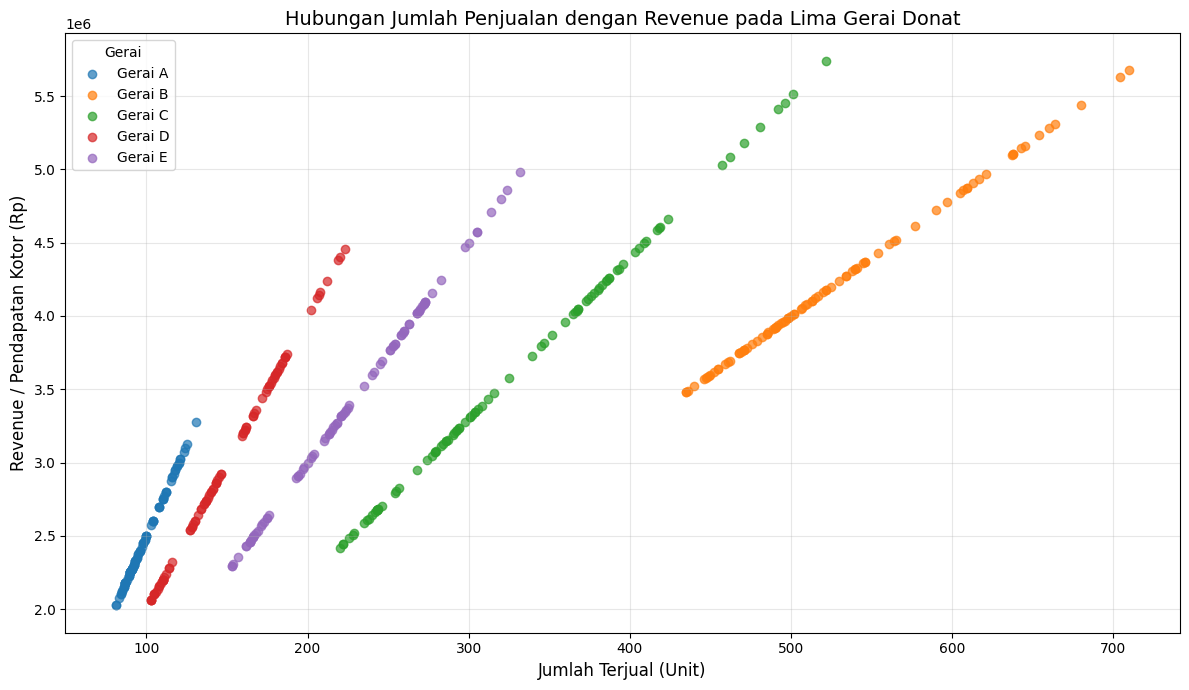

In [11]:
plt.figure(figsize=(12, 7))

gerai_list = sorted(df["Gerai"].unique())

for gerai in gerai_list:
    data_gerai = df[df["Gerai"] == gerai]

    plt.scatter(
        data_gerai["Jumlah Terjual (Unit)"],
        data_gerai["Pendapatan Kotor (Rp)"],
        label=gerai,
        alpha=0.7
    )

plt.title("Hubungan Jumlah Penjualan dengan Revenue pada Lima Gerai Donat",
          fontsize=14)
plt.xlabel("Jumlah Terjual (Unit)", fontsize=12)
plt.ylabel("Revenue / Pendapatan Kotor (Rp)", fontsize=12)

plt.legend(title="Gerai")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

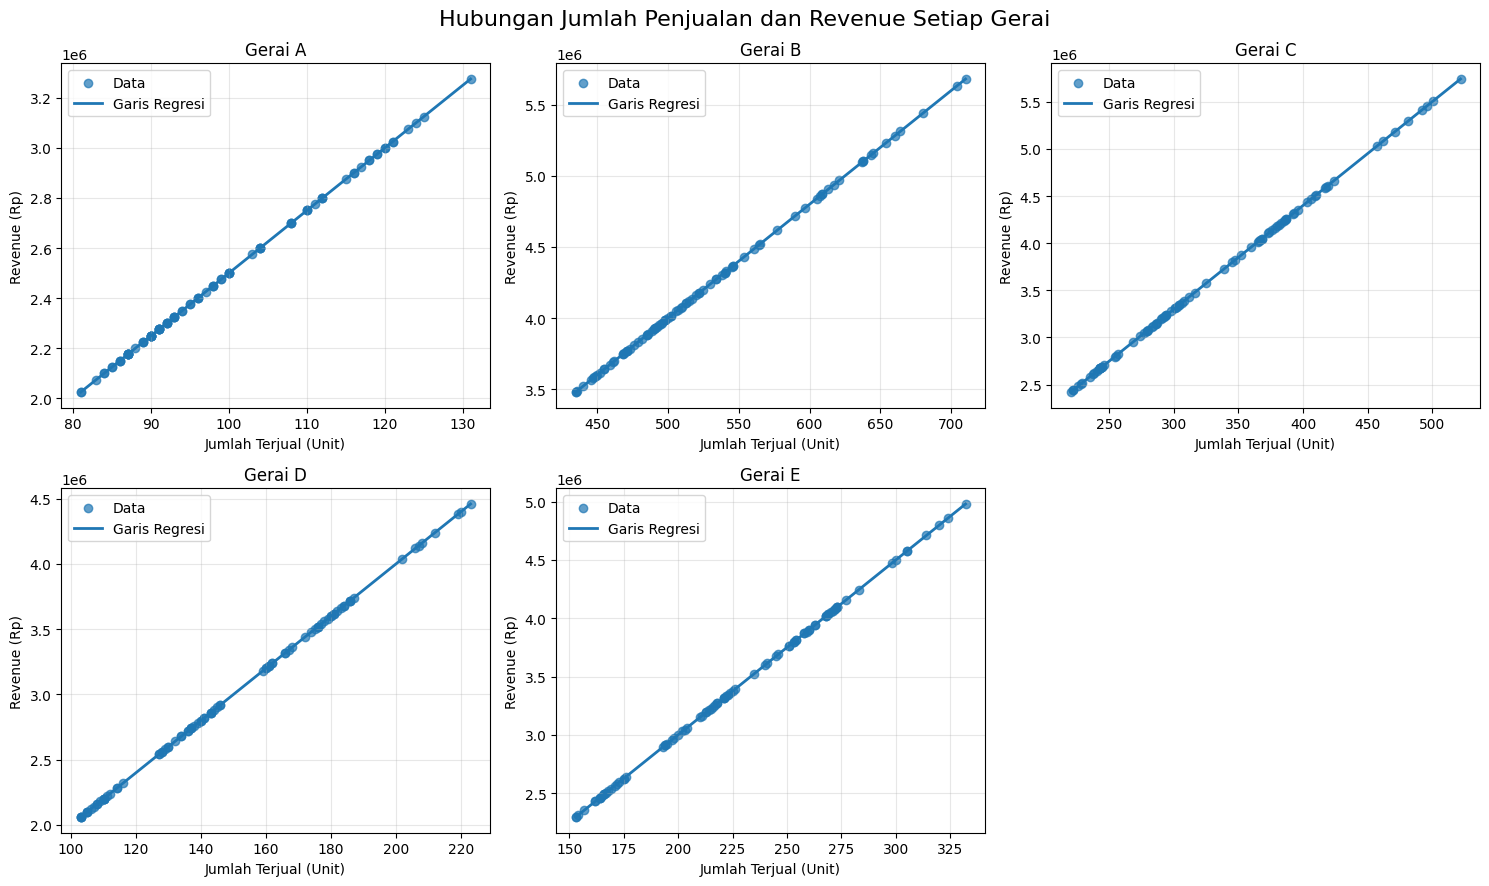

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, gerai in enumerate(gerai_list):
    data_gerai = df[df["Gerai"] == gerai]

    x = data_gerai["Jumlah Terjual (Unit)"]
    y = data_gerai["Pendapatan Kotor (Rp)"]

    # Regresi linear sementara untuk garis tren
    koef = np.polyfit(x, y, 1)
    model = np.poly1d(koef)

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = model(x_line)

    axes[i].scatter(x, y, alpha=0.7, label="Data")
    axes[i].plot(x_line, y_line, linewidth=2, label="Garis Regresi")

    axes[i].set_title(gerai)
    axes[i].set_xlabel("Jumlah Terjual (Unit)")
    axes[i].set_ylabel("Revenue (Rp)")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

# Menghilangkan subplot kosong
if len(gerai_list) < len(axes):
    for j in range(len(gerai_list), len(axes)):
        fig.delaxes(axes[j])

fig.suptitle(
    "Hubungan Jumlah Penjualan dan Revenue Setiap Gerai",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Interpretasi

Berdasarkan scatter plot, terlihat adanya hubungan positif antara jumlah
penjualan dan revenue pada seluruh gerai. Artinya, ketika jumlah produk yang
terjual meningkat, revenue juga cenderung meningkat.

Kemiringan hubungan berbeda antar gerai karena setiap gerai memiliki harga
jual per unit yang berbeda. Oleh karena itu, kenaikan revenue untuk setiap
tambahan unit penjualan juga berbeda.

Pola hubungan yang terlihat cenderung linear, sehingga regresi linear dapat
digunakan sebagai salah satu model awal untuk menggambarkan hubungan antara
volume penjualan dan revenue. Selanjutnya, beberapa model regresi akan
dibandingkan untuk menentukan model yang paling sesuai dengan karakteristik
data masing-masing gerai.

## 4. Analisis Regresi

Regresi digunakan untuk mengetahui hubungan matematis antara jumlah penjualan sebagai variabel independen (X) dan revenue sebagai variabel dependen (Y).

Pada tahap ini digunakan dua model, yaitu regresi linear dan regresi polynomial orde 2. Kedua model dibandingkan menggunakan nilai R² dan RMSE.

R² menunjukkan tingkat kemampuan model dalam menjelaskan variasi data, sedangkan RMSE menunjukkan besar kesalahan prediksi model.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

In [14]:
hasil_regresi = []

for gerai in sorted(df["Gerai"].unique()):

    data_gerai = df[df["Gerai"] == gerai]

    X = data_gerai[["Jumlah Terjual (Unit)"]]
    y = data_gerai["Pendapatan Kotor (Rp)"]

    # =========================
    # REGRESI LINEAR
    # =========================
    model_linear = LinearRegression()
    model_linear.fit(X, y)

    y_pred_linear = model_linear.predict(X)

    r2_linear = r2_score(y, y_pred_linear)
    rmse_linear = np.sqrt(mean_squared_error(y, y_pred_linear))

    # =========================
    # REGRESI POLYNOMIAL ORDE 2
    # =========================
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)

    y_pred_poly = model_poly.predict(X_poly)

    r2_poly = r2_score(y, y_pred_poly)
    rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))

    hasil_regresi.append({
        "Gerai": gerai,
        "R2 Linear": r2_linear,
        "RMSE Linear": rmse_linear,
        "R2 Polynomial": r2_poly,
        "RMSE Polynomial": rmse_poly
    })

hasil_regresi_df = pd.DataFrame(hasil_regresi)

hasil_regresi_df

,Gerai,R2 Linear,RMSE Linear,R2 Polynomial,RMSE Polynomial
0,Gerai A,1.0,3.283563e-10,1.0,2.683002e-09
1,Gerai B,1.0,0.000000e+00,1.0,2.026902e-08
2,Gerai C,1.0,0.000000e+00,1.0,9.623966e-08
3,Gerai D,1.0,4.444837e-10,1.0,3.532416e-09
4,Gerai E,1.0,0.000000e+00,1.0,2.300192e-08


In [15]:
print("PERSAMAAN REGRESI LINEAR")
print("=" * 60)

model_linear_dict = {}

for gerai in sorted(df["Gerai"].unique()):

    data_gerai = df[df["Gerai"] == gerai]

    X = data_gerai[["Jumlah Terjual (Unit)"]]
    y = data_gerai["Pendapatan Kotor (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    a = model.coef_[0]
    b = model.intercept_

    model_linear_dict[gerai] = {
        "a": a,
        "b": b,
        "model": model
    }

    print(f"{gerai}:")
    print(f"Revenue = {a:.2f} × Jumlah Terjual + ({b:.2f})")
    print(f"R² = {model.score(X, y):.6f}")
    print()

PERSAMAAN REGRESI LINEAR
Gerai A:
Revenue = 25000.00 × Jumlah Terjual + (-0.00)
R² = 1.000000

Gerai B:
Revenue = 8000.00 × Jumlah Terjual + (0.00)
R² = 1.000000

Gerai C:
Revenue = 11000.00 × Jumlah Terjual + (0.00)
R² = 1.000000

Gerai D:
Revenue = 20000.00 × Jumlah Terjual + (-0.00)
R² = 1.000000

Gerai E:
Revenue = 15000.00 × Jumlah Terjual + (-0.00)
R² = 1.000000



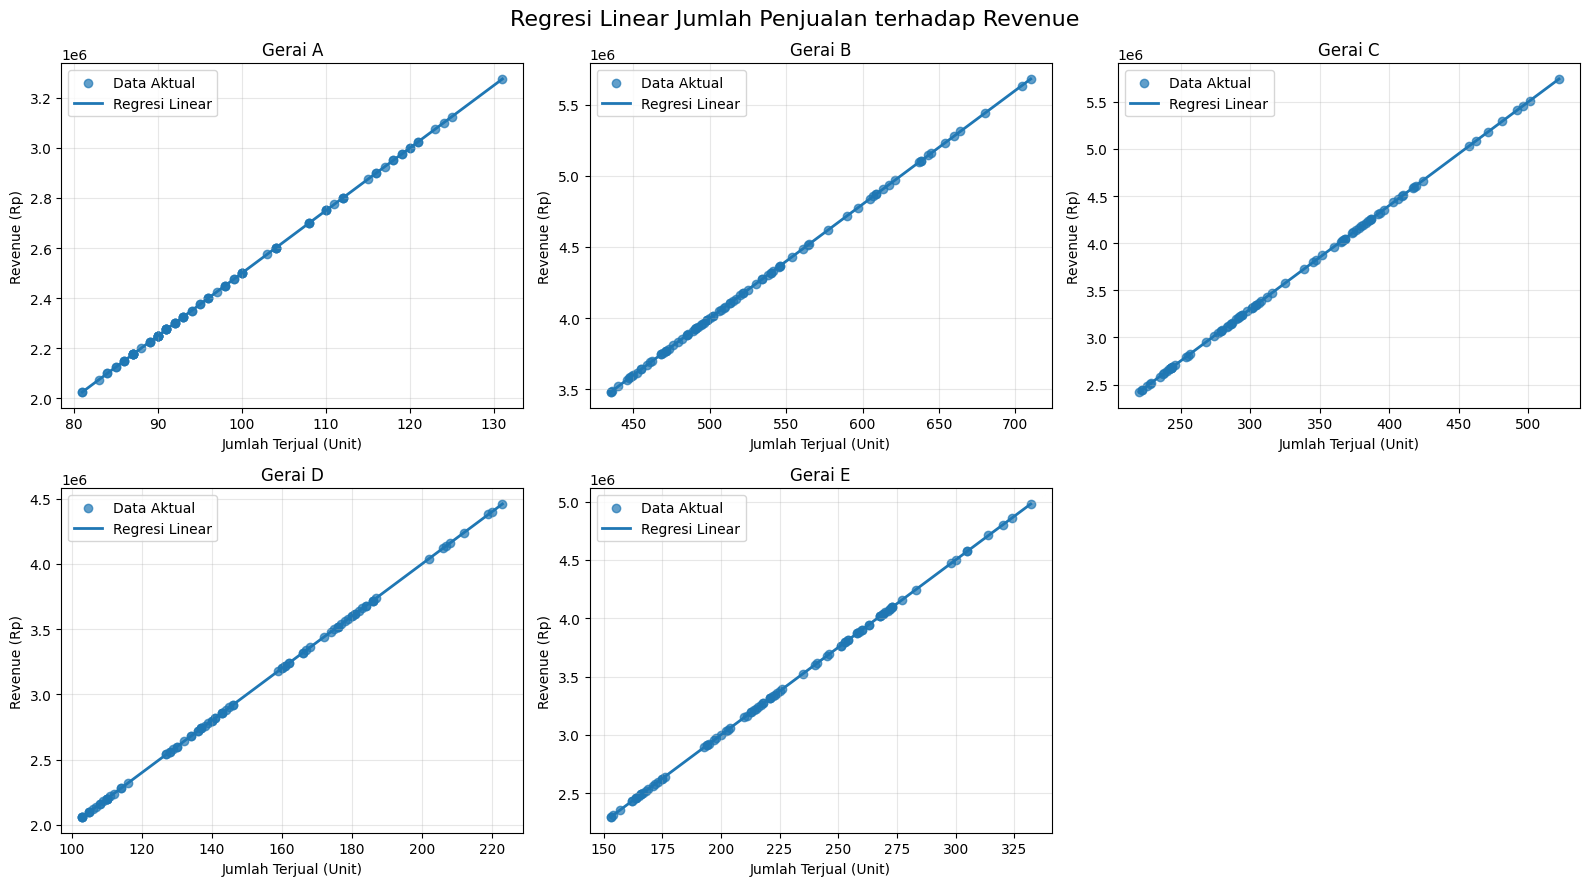

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, gerai in enumerate(gerai_list):

    data_gerai = df[df["Gerai"] == gerai]

    X = data_gerai[["Jumlah Terjual (Unit)"]]
    y = data_gerai["Pendapatan Kotor (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    # Membuat X untuk garis regresi
    x_plot = pd.DataFrame({
        "Jumlah Terjual (Unit)": np.linspace(
            X["Jumlah Terjual (Unit)"].min(),
            X["Jumlah Terjual (Unit)"].max(),
            100
        )
    })

    y_plot = model.predict(x_plot)

    axes[i].scatter(
        X["Jumlah Terjual (Unit)"],
        y,
        alpha=0.7,
        label="Data Aktual"
    )

    axes[i].plot(
        x_plot["Jumlah Terjual (Unit)"],
        y_plot,
        linewidth=2,
        label="Regresi Linear"
    )

    axes[i].set_title(gerai)
    axes[i].set_xlabel("Jumlah Terjual (Unit)")
    axes[i].set_ylabel("Revenue (Rp)")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

fig.delaxes(axes[5])

fig.suptitle(
    "Regresi Linear Jumlah Penjualan terhadap Revenue",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Perbandingan Regresi Linear dan Polynomial

Untuk memastikan model yang digunakan sesuai dengan pola data, regresi linear dibandingkan dengan regresi polynomial orde 2 secara visual.

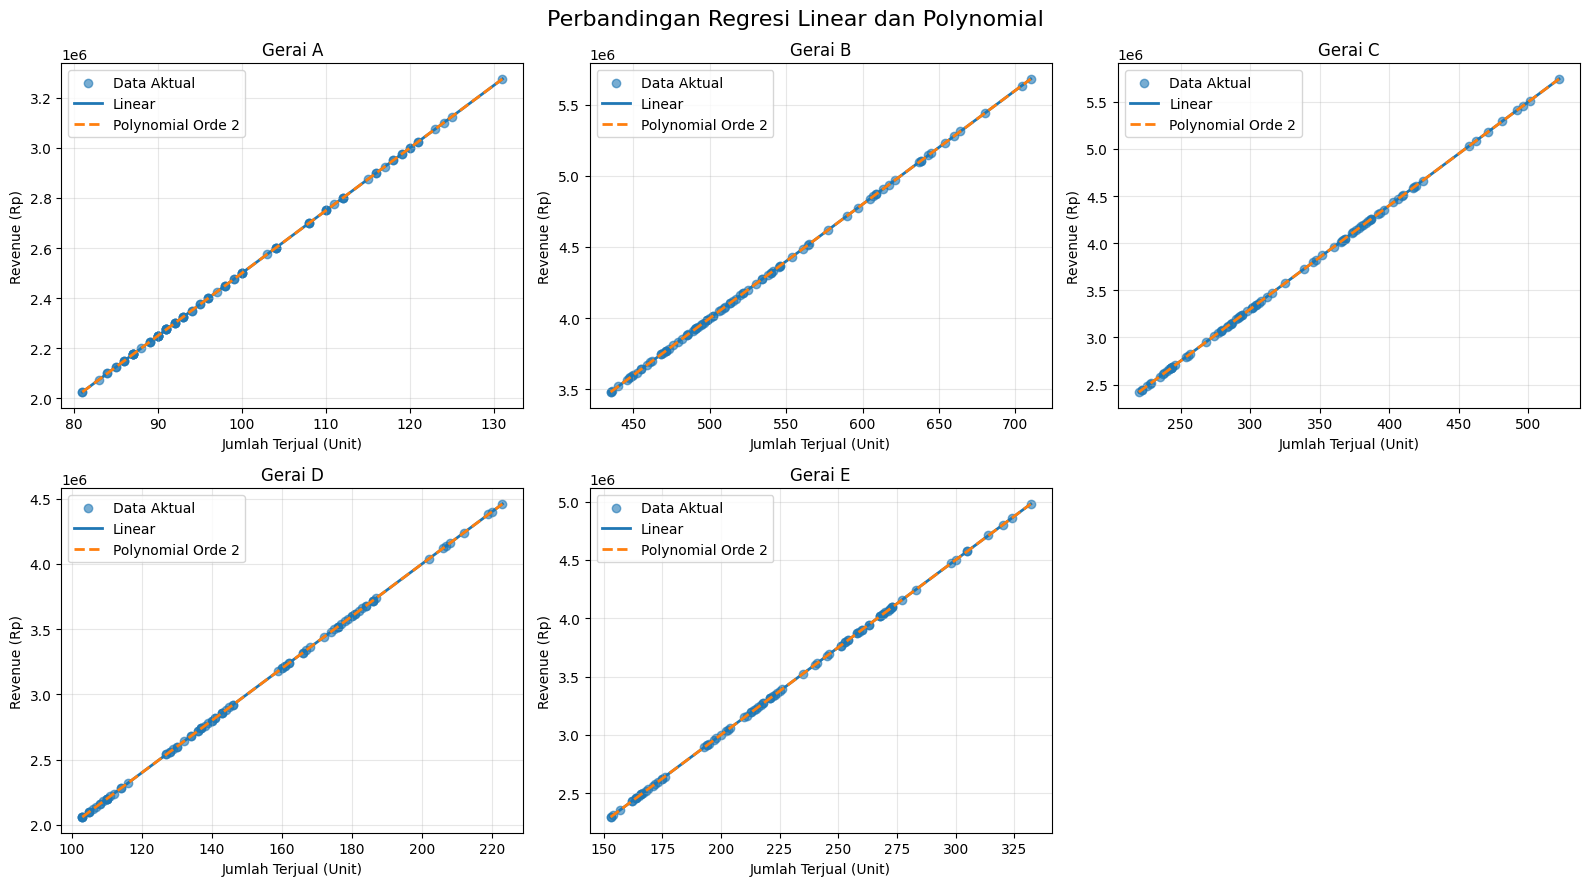

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, gerai in enumerate(gerai_list):

    data_gerai = df[df["Gerai"] == gerai]

    X = data_gerai[["Jumlah Terjual (Unit)"]]
    y = data_gerai["Pendapatan Kotor (Rp)"]

    # Model linear
    model_linear = LinearRegression()
    model_linear.fit(X, y)

    # Model polynomial
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)

    # Data untuk garis
    x_plot = pd.DataFrame({
        "Jumlah Terjual (Unit)": np.linspace(
            X["Jumlah Terjual (Unit)"].min(),
            X["Jumlah Terjual (Unit)"].max(),
            200
        )
    })

    y_linear = model_linear.predict(x_plot)

    x_plot_poly = poly.transform(x_plot)
    y_poly = model_poly.predict(x_plot_poly)

    axes[i].scatter(
        X["Jumlah Terjual (Unit)"],
        y,
        alpha=0.6,
        label="Data Aktual"
    )

    axes[i].plot(
        x_plot["Jumlah Terjual (Unit)"],
        y_linear,
        linewidth=2,
        label="Linear"
    )

    axes[i].plot(
        x_plot["Jumlah Terjual (Unit)"],
        y_poly,
        linewidth=2,
        linestyle="--",
        label="Polynomial Orde 2"
    )

    axes[i].set_title(gerai)
    axes[i].set_xlabel("Jumlah Terjual (Unit)")
    axes[i].set_ylabel("Revenue (Rp)")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

fig.delaxes(axes[5])

fig.suptitle(
    "Perbandingan Regresi Linear dan Polynomial",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Interpretasi Hasil Regresi

Hasil regresi menunjukkan bahwa model linear memiliki nilai R² yang sangat tinggi dan RMSE yang sangat mendekati nol pada seluruh gerai. Hal ini menunjukkan bahwa hubungan antara jumlah penjualan dan revenue pada dataset dapat direpresentasikan dengan model linear dengan sangat baik.

Model polynomial orde 2 juga menghasilkan kecocokan yang sangat tinggi. Namun, model linear digunakan sebagai model utama karena hubungan antara jumlah penjualan dan revenue pada dataset bersifat linear. Selain itu, model linear memiliki bentuk persamaan yang lebih sederhana sehingga lebih mudah digunakan pada proses pemodelan fungsi balance dan pencarian Breakeven Point menggunakan metode Bisection.

Dengan demikian, persamaan regresi linear digunakan sebagai fungsi revenue pada tahap pencarian BEP.

## 5. Pemodelan Revenue dan Biaya

Untuk menentukan Breakeven Point, diperlukan fungsi balance yang menunjukkan selisih antara revenue dan total biaya.

Model yang digunakan adalah:

Revenue(x) = aᵣx + bᵣ

Biaya Variabel(x) = aᵥx + bᵥ

Balance(x) = Revenue(x) - Biaya Variabel(x) - Fixed Cost

dengan x merupakan jumlah unit yang terjual.

Parameter revenue diperoleh dari regresi linear. Biaya variabel juga dimodelkan terhadap jumlah penjualan, sedangkan fixed cost menggunakan nilai rata-rata fixed cost masing-masing gerai.

In [29]:
parameter_gerai = {}

for gerai in gerai_list:

    data_gerai = df[df["Gerai"] == gerai]

    X = data_gerai[["Jumlah Terjual (Unit)"]]

    # =========================
    # REGRESI REVENUE
    # =========================

    y_revenue = data_gerai["Pendapatan Kotor (Rp)"]

    model_revenue = LinearRegression()
    model_revenue.fit(X, y_revenue)

    a_revenue = model_revenue.coef_[0]
    b_revenue = model_revenue.intercept_

    # =========================
    # REGRESI BIAYA VARIABEL
    # =========================

    y_biaya = data_gerai["Biaya Variabel (Rp)"]

    model_biaya = LinearRegression()
    model_biaya.fit(X, y_biaya)

    a_biaya = model_biaya.coef_[0]
    b_biaya = model_biaya.intercept_

    # =========================
    # FIXED COST
    # =========================

    fixed_cost = data_gerai[
        "Fixed Cost Harian (Rp)"
    ].mean()

    parameter_gerai[gerai] = {
        "a_revenue": a_revenue,
        "b_revenue": b_revenue,
        "a_biaya": a_biaya,
        "b_biaya": b_biaya,
        "fixed_cost": fixed_cost
    }

display(
    pd.DataFrame(parameter_gerai).T
)

,a_revenue,b_revenue,a_biaya,b_biaya,fixed_cost
Gerai A,25000.0,-4.656613e-10,8500.0,-1.164153e-10,1683333.0
Gerai B,8000.0,0.000000e+00,4160.0,-4.656613e-10,733333.0
Gerai C,11000.0,4.656613e-10,4840.0,2.328306e-10,1733333.0
Gerai D,20000.0,-9.313226e-10,7200.0,0.000000e+00,2666666.0
Gerai E,15000.0,-4.656613e-10,6300.0,0.000000e+00,800000.0


## 6. Fungsi Balance dan Pencarian Akar

Breakeven Point merupakan kondisi ketika balance sama dengan nol.

Oleh karena itu, pencarian BEP dapat dinyatakan sebagai pencarian akar persamaan:

f(x) = Balance(x) = 0

Nilai x yang memenuhi persamaan tersebut merupakan jumlah penjualan pada titik impas.

In [30]:
def fungsi_balance(x, parameter):

    revenue = (
        parameter["a_revenue"] * x
        + parameter["b_revenue"]
    )

    biaya_variabel = (
        parameter["a_biaya"] * x
        + parameter["b_biaya"]
    )

    balance = (
        revenue
        - biaya_variabel
        - parameter["fixed_cost"]
    )

    return balance

### Metode Bisection

Metode Bisection digunakan untuk mencari akar fungsi balance secara numerik.

Syarat utama metode Bisection adalah:

f(a) × f(b) < 0

Artinya, nilai fungsi pada kedua ujung interval harus memiliki tanda yang berbeda. Interval kemudian dibagi menjadi dua secara berulang sampai memenuhi kriteria toleransi.

In [32]:
def bisection(f, a, b, tol=1e-6, max_iter=100):

    fa = f(a)
    fb = f(b)

    # Validasi interval
    if fa == 0:
        return a, pd.DataFrame()

    if fb == 0:
        return b, pd.DataFrame()

    if fa * fb > 0:
        raise ValueError(
            "Interval tidak memenuhi syarat f(a) × f(b) < 0."
        )

    hasil_iterasi = []

    for i in range(1, max_iter + 1):

        c = (a + b) / 2
        fc = f(c)

        error = abs(b - a) / 2

        hasil_iterasi.append({
            "Iterasi": i,
            "a": a,
            "b": b,
            "c": c,
            "f(a)": fa,
            "f(b)": fb,
            "f(c)": fc,
            "Error": error
        })

        # Kondisi berhenti
        if abs(fc) < tol or error < tol:
            return c, pd.DataFrame(hasil_iterasi)

        # Menentukan interval baru
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    return c, pd.DataFrame(hasil_iterasi)

In [39]:
print("PEMERIKSAAN SYARAT BISECTION")
print("=" * 60)

for _, row in hasil_bep_df.iterrows():
    memenuhi_syarat = row["f(0)"] * row["f(max)"] < 0

    print(
        f"{row['Gerai']}: "
        f"f(0) × f(max) < 0 → {memenuhi_syarat}"
    )

PEMERIKSAAN SYARAT BISECTION
Gerai A: f(0) × f(max) < 0 → True
Gerai B: f(0) × f(max) < 0 → True
Gerai C: f(0) × f(max) < 0 → True
Gerai D: f(0) × f(max) < 0 → True
Gerai E: f(0) × f(max) < 0 → True


## 7. Breakeven Point (BEP)

Breakeven Point (BEP) merupakan kondisi ketika total pendapatan sama dengan total biaya sehingga nilai balance sama dengan nol.

Pada penelitian ini, BEP dicari dengan menggunakan metode Bisection terhadap fungsi balance yang telah dibentuk sebelumnya.

In [33]:
hasil_bep = []

for gerai in gerai_list:

    parameter = parameter_gerai[gerai]

    f = lambda x: fungsi_balance(x, parameter)

    # Interval awal
    a = 0
    b = df[
        df["Gerai"] == gerai
    ]["Jumlah Terjual (Unit)"].max()

    # Nilai fungsi pada batas interval
    fa = f(a)
    fb = f(b)

    # Bisection
    bep, tabel_iterasi = bisection(
        f,
        a,
        b,
        tol=1e-6,
        max_iter=100
    )

    # Pembulatan ke atas karena jumlah unit harus bilangan bulat
    bep_bulat = int(np.ceil(bep))

    # Validasi BEP
    balance_sebelum = f(bep_bulat - 1)
    balance_sesudah = f(bep_bulat)

    hasil_bep.append({
        "Gerai": gerai,
        "f(0)": fa,
        "f(max)": fb,
        "BEP Kontinu (Unit)": bep,
        "BEP Bulat (Unit)": bep_bulat,
        "Balance Sebelum BEP": balance_sebelum,
        "Balance Setelah BEP": balance_sesudah,
        "Jumlah Iterasi": len(tabel_iterasi)
    })

hasil_bep_df = pd.DataFrame(hasil_bep)

display(hasil_bep_df)

,Gerai,f(0),f(max),BEP Kontinu (Unit),BEP Bulat (Unit),Balance Sebelum BEP,Balance Setelah BEP,Jumlah Iterasi
0,Gerai A,-1683333.0,478167.0,102.020183,103,-333.0,16167.0,27
1,Gerai B,-733333.0,1993067.0,190.972135,191,-3733.0,107.0,30
2,Gerai C,-1733333.0,1482187.0,281.385228,282,-2373.0,3787.0,29
3,Gerai D,-2666666.0,187734.0,208.333281,209,-4266.0,8534.0,28
4,Gerai E,-800000.0,2088400.0,91.954023,92,-8300.0,400.0,29


### 7.1 Validasi Hasil BEP

Hasil BEP kontinu diperoleh dari metode Bisection. Karena jumlah produk yang dijual harus berupa bilangan bulat, nilai BEP kemudian dibulatkan ke atas.

Validasi dilakukan dengan membandingkan balance pada satu unit sebelum BEP dan pada nilai BEP. Nilai yang diharapkan adalah:

Balance sebelum BEP < 0

Balance pada BEP ≥ 0

Dengan demikian, nilai BEP bulat merupakan jumlah minimum unit yang harus terjual agar gerai mencapai kondisi impas atau tidak mengalami kerugian.

In [34]:
print("VALIDASI BREAKEVEN POINT")
print("=" * 80)

for _, row in hasil_bep_df.iterrows():

    print(f"\n{row['Gerai']}")
    print(
        f"BEP kontinu       : "
        f"{row['BEP Kontinu (Unit)']:.6f} unit"
    )
    print(
        f"BEP dibulatkan    : "
        f"{row['BEP Bulat (Unit)']} unit"
    )
    print(
        f"Balance sebelum   : "
        f"Rp {row['Balance Sebelum BEP']:,.2f}"
    )
    print(
        f"Balance pada BEP  : "
        f"Rp {row['Balance Setelah BEP']:,.2f}"
    )
    print(
        f"Jumlah iterasi    : "
        f"{row['Jumlah Iterasi']}"
    )

VALIDASI BREAKEVEN POINT

Gerai A
BEP kontinu       : 102.020183 unit
BEP dibulatkan    : 103 unit
Balance sebelum   : Rp -333.00
Balance pada BEP  : Rp 16,167.00
Jumlah iterasi    : 27

Gerai B
BEP kontinu       : 190.972135 unit
BEP dibulatkan    : 191 unit
Balance sebelum   : Rp -3,733.00
Balance pada BEP  : Rp 107.00
Jumlah iterasi    : 30

Gerai C
BEP kontinu       : 281.385228 unit
BEP dibulatkan    : 282 unit
Balance sebelum   : Rp -2,373.00
Balance pada BEP  : Rp 3,787.00
Jumlah iterasi    : 29

Gerai D
BEP kontinu       : 208.333281 unit
BEP dibulatkan    : 209 unit
Balance sebelum   : Rp -4,266.00
Balance pada BEP  : Rp 8,534.00
Jumlah iterasi    : 28

Gerai E
BEP kontinu       : 91.954023 unit
BEP dibulatkan    : 92 unit
Balance sebelum   : Rp -8,300.00
Balance pada BEP  : Rp 400.00
Jumlah iterasi    : 29


In [35]:
tabel_akhir = hasil_bep_df[
    [
        "Gerai",
        "BEP Kontinu (Unit)",
        "BEP Bulat (Unit)",
        "Jumlah Iterasi"
    ]
].copy()

tabel_akhir["BEP Kontinu (Unit)"] = (
    tabel_akhir["BEP Kontinu (Unit)"]
    .round(4)
)

display(tabel_akhir)

,Gerai,BEP Kontinu (Unit),BEP Bulat (Unit),Jumlah Iterasi
0,Gerai A,102.0202,103,27
1,Gerai B,190.9721,191,30
2,Gerai C,281.3852,282,29
3,Gerai D,208.3333,209,28
4,Gerai E,91.9540,92,29


In [36]:
print("PERSAMAAN BALANCE SETIAP GERAI")
print("=" * 80)

for gerai in gerai_list:

    p = parameter_gerai[gerai]

    koef_x = p["a_revenue"] - p["a_biaya"]
    konstanta = (
        p["b_revenue"]
        - p["b_biaya"]
        - p["fixed_cost"]
    )

    print(f"{gerai}:")
    print(
        f"Balance(x) = "
        f"{koef_x:.2f} × x + ({konstanta:.2f})"
    )
    print()

PERSAMAAN BALANCE SETIAP GERAI
Gerai A:
Balance(x) = 16500.00 × x + (-1683333.00)

Gerai B:
Balance(x) = 3840.00 × x + (-733333.00)

Gerai C:
Balance(x) = 6160.00 × x + (-1733333.00)

Gerai D:
Balance(x) = 12800.00 × x + (-2666666.00)

Gerai E:
Balance(x) = 8700.00 × x + (-800000.00)



In [37]:
tabel_parameter = []

for gerai in gerai_list:

    p = parameter_gerai[gerai]

    tabel_parameter.append({
        "Gerai": gerai,
        "Koef. Revenue": p["a_revenue"],
        "Konstanta Revenue": p["b_revenue"],
        "Koef. Biaya Variabel": p["a_biaya"],
        "Konstanta Biaya": p["b_biaya"],
        "Fixed Cost": p["fixed_cost"]
    })

tabel_parameter_df = pd.DataFrame(tabel_parameter)

display(tabel_parameter_df)

,Gerai,Koef. Revenue,Konstanta Revenue,Koef. Biaya Variabel,Konstanta Biaya,Fixed Cost
0,Gerai A,25000.0,-4.656613e-10,8500.0,-1.164153e-10,1683333.0
1,Gerai B,8000.0,0.000000e+00,4160.0,-4.656613e-10,733333.0
2,Gerai C,11000.0,4.656613e-10,4840.0,2.328306e-10,1733333.0
3,Gerai D,20000.0,-9.313226e-10,7200.0,0.000000e+00,2666666.0
4,Gerai E,15000.0,-4.656613e-10,6300.0,0.000000e+00,800000.0


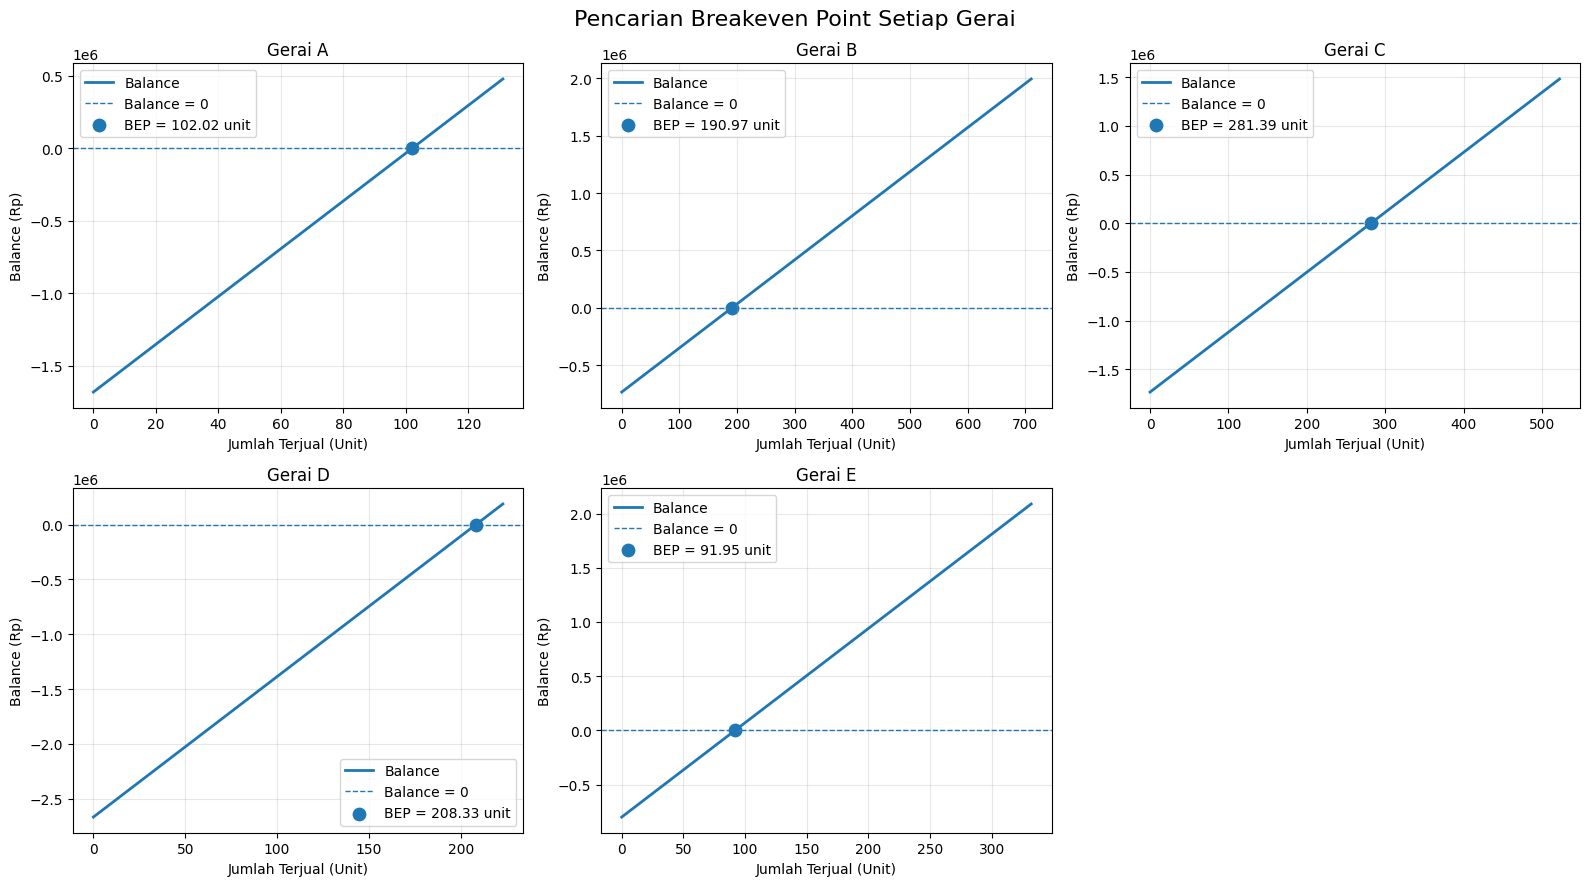

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, gerai in enumerate(gerai_list):

    parameter = parameter_gerai[gerai]

    f = lambda x: fungsi_balance(x, parameter)

    bep = hasil_bep_df.loc[
        hasil_bep_df["Gerai"] == gerai,
        "BEP Kontinu (Unit)"
    ].iloc[0]

    x_max = df[
        df["Gerai"] == gerai
    ]["Jumlah Terjual (Unit)"].max()

    x_plot = np.linspace(0, x_max, 200)
    y_plot = [f(x) for x in x_plot]

    axes[i].plot(
        x_plot,
        y_plot,
        linewidth=2,
        label="Balance"
    )

    axes[i].axhline(
        0,
        linestyle="--",
        linewidth=1,
        label="Balance = 0"
    )

    axes[i].scatter(
        bep,
        0,
        s=80,
        label=f"BEP = {bep:.2f} unit"
    )

    axes[i].set_title(gerai)
    axes[i].set_xlabel("Jumlah Terjual (Unit)")
    axes[i].set_ylabel("Balance (Rp)")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

fig.delaxes(axes[5])

fig.suptitle(
    "Pencarian Breakeven Point Setiap Gerai",
    fontsize=16
)

plt.tight_layout()
plt.show()

### 7.2 Interpretasi Grafik BEP

Grafik menunjukkan hubungan antara jumlah unit yang terjual dengan balance masing-masing gerai. Titik BEP berada pada saat garis balance memotong garis horizontal Balance = 0.

Pada jumlah penjualan di bawah BEP, balance bernilai negatif sehingga gerai berada pada kondisi belum mencapai titik impas. Setelah melewati BEP, balance menjadi positif sehingga pendapatan telah mampu menutupi biaya variabel dan fixed cost.

Perbedaan posisi BEP antar gerai dipengaruhi oleh harga jual, biaya variabel, dan fixed cost masing-masing gerai.

## 8. Kesimpulan

Berdasarkan hasil analisis data penjualan lima gerai donat, diperoleh beberapa kesimpulan sebagai berikut:

1. Visualisasi menunjukkan adanya hubungan positif antara jumlah penjualan dan revenue pada seluruh gerai. Semakin banyak unit yang terjual, semakin besar revenue yang diperoleh.

2. Hasil analisis regresi menunjukkan bahwa hubungan antara jumlah penjualan dan revenue dapat dimodelkan dengan regresi linear dengan tingkat kecocokan yang sangat tinggi. Model linear kemudian digunakan sebagai fungsi revenue karena sesuai dengan pola data dan memiliki bentuk persamaan yang sederhana.

3. Untuk menentukan Breakeven Point, dibentuk fungsi balance yang merupakan selisih antara revenue, biaya variabel, dan fixed cost.

4. Metode Bisection digunakan untuk mencari akar dari fungsi balance, yaitu kondisi ketika balance = 0. Hasil perhitungan menghasilkan nilai BEP untuk masing-masing gerai.

5. Nilai BEP kontinu kemudian dibulatkan ke atas untuk mendapatkan jumlah unit minimum yang harus terjual agar balance tidak negatif.

6. Perbedaan nilai BEP antar gerai berkaitan dengan perbedaan harga jual, biaya variabel, dan fixed cost yang digunakan pada masing-masing gerai.

Dengan demikian, analisis telah mencakup visualisasi hubungan penjualan dan revenue, pemodelan regresi, serta pencarian Breakeven Point menggunakan metode numerik Bisection.